# **0- SETUP**

In [ ]:
!pip install -q langdetect wordcloud arabic-reshaper python-bidi transformers accelerate torch scikit-learn plotly nltk sentencepiece

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 12.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.2/296.2 kB 24.6 MB/s eta 0:00:00


In [ ]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
import re
import gc
import unicodedata
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import matplotlib.pyplot as plt
from matplotlib import font_manager
from wordcloud import WordCloud
from collections import Counter
import random
import arabic_reshaper
from bidi.algorithm import get_display
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords", quiet=True)
from langdetect import detect, LangDetectException
import torch
from transformers import (
AutoTokenizer,
AutoModelForSequenceClassification,
Trainer,
TrainingArguments,
DataCollatorWithPadding,
)
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
print("Torch CUDA available:", torch.cuda.is_available())
assert torch.cuda.is_available(), "No GPU detected — go to Runtime > Change runtime type > T4 GPU before continuing."

Torch CUDA available: True


In [ ]:
def free_memory(*names):
    """Delete named variables from globals and clear GPU cache. Call after every model block."""
    for name in names:
        if name in globals():
            del globals()[name]
    gc.collect()
    torch.cuda.empty_cache()

In [ ]:
# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# **1- Data Loading**

In [ ]:
# Update these paths to wherever you upload the files in Colab (e.g. /content/ or a mounted Drive folder)
DATA_DIR = "/content"

main = pd.read_csv(f"{DATA_DIR}/data_reviews.csv", header=0)
aux = pd.read_csv(f"{DATA_DIR}/restaurant_reviews_v2.csv")
submission = pd.read_csv(f"{DATA_DIR}/sample_submition.csv")
test = pd.read_csv(f"{DATA_DIR}/test_food.csv")

print("main:", main.shape, "| aux:", aux.shape, "| test:", test.shape, "| submission:", submission.shape)

main: (1138, 7) | aux: (8769, 3) | test: (1288, 2) | submission: (4, 2)


# **2- Initial Stats & Data Quality Checks**

In [ ]:
print("=== main info ===")
main.info()
print("\n=== missing values ===")
print(main.isna().sum())
print("\n=== unique Sentiment values ===")
print(main["Sentiment"].unique())
print("\n=== unique Language values ===")
print(main["Language"].unique())

=== main info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1138 entries, 0 to 1137
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Unnamed: 0    1138 non-null   int64 
 1   Review_Text   1138 non-null   object
 2   Language      1138 non-null   object
 3   Rating (1-5)  1138 non-null   object
 4   Country       1138 non-null   object
 5   Sentiment     1138 non-null   object
 6   Aspect_Focus  1138 non-null   object
dtypes: int64(1), object(6)
memory usage: 62.4+ KB

=== missing values ===
Unnamed: 0      0
Review_Text     0
Language        0
Rating (1-5)    0
Country         0
Sentiment       0
Aspect_Focus    0
dtype: int64

=== unique Sentiment values ===
['Positive' 'Negative' 'Sentiment (Positive/Negative)' 'Positif']

=== unique Language values ===
['French' 'Arabic' 'English' 'Language']


In [ ]:
print("=== aux info ===")
aux.info()
print("\n=== missing values ===")
print(aux.isna().sum())

=== aux info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8769 entries, 0 to 8768
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   restaurant_id  8769 non-null   object
 1   text           8693 non-null   object
 2   stars          8769 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 205.7+ KB

=== missing values ===
restaurant_id     0
text             76
stars             0
dtype: int64


In [ ]:
print("=== test info ===")
test.info()
print("\n=== missing values ===")
print(test.isna().sum())

=== test info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1288 entries, 0 to 1287
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   iD           1288 non-null   object
 1   review_text  1287 non-null   object
dtypes: object(2)
memory usage: 20.3+ KB

=== missing values ===
iD             0
review_text    1
dtype: int64


In [ ]:
# Duplicate checks (not in the original notebook, worth reporting)
print("Duplicate rows in main:", main.duplicated(subset=["Review_Text"]).sum())
print("Duplicate rows in aux:", aux.duplicated(subset=["text"]).sum())
print("Duplicate rows in test:", test.duplicated(subset=["review_text"]).sum())

Duplicate rows in main: 757
Duplicate rows in aux: 503
Duplicate rows in test: 68


In [ ]:
# Drop rows with missing text (aux/test have real NAs per the info() checks above)
aux = aux.dropna(subset=["text"]).copy()
test = test.dropna(subset=["review_text"]).copy()
print("aux after dropna:", aux.shape, "| test after dropna:", test.shape)

aux after dropna: (8693, 3) | test after dropna: (1287, 2)


# **3- Data Preparation & Cleaning**

In [ ]:
# --- main: drop index artifact, fix messy label values ---
if "Unnamed: 0" in main.columns:
    main = main.drop(columns=["Unnamed: 0"])

main["Sentiment"] = main["Sentiment"].str.lower().replace({"positif": "positive"})

# Drop stray header rows that leaked into the data (seen in value_counts: "Sentiment (Positive/Negative)")
main = main[main["Language"] != "Language"]
main = main[~main["Sentiment"].isin(["sentiment (positive/negative)"])]
main = main[main["Sentiment"].isin(["positive", "negative", "neutral"])]

print(main["Sentiment"].value_counts())

Sentiment
positive    723
negative    413
Name: count, dtype: int64


In [ ]:
# --- Rename columns to a consistent schema across all 3 dataframes ---
main = main.rename(columns={"Rating (1-5)": "Rating", "Review_Text": "Text"})
aux = aux.rename(columns={"stars": "Rating", "text": "Text"})
test = test.rename(columns={"review_text": "Text"})

# --- Fix dtypes ---
main = main[main["Rating"] != "Rating (1-5)"]
main["Rating"] = main["Rating"].astype(int)
aux["Rating"] = pd.to_numeric(aux["Rating"], errors="coerce")

main.head()

,Text,Language,Rating,Country,Sentiment,Aspect_Focus
0,La livraison a été très rapide et le repas éta...,French,5,Algeria,positive,Delivery Speed
1,الأكل وصل باردًا ولم يكن طازجًا كما توقعت.,Arabic,2,Algeria,negative,Food Quality
2,The food was delicious and the delivery was pr...,English,5,Algeria,positive,Food Quality
3,La plateforme a des problèmes de connexion fré...,French,2,Algeria,negative,App Usability
4,خدمة التوصيل ممتازة والأسعار مناسبة.,Arabic,5,Algeria,positive,Pricing


In [ ]:
def clean_text(text):
    """Lowercase, strip URLs, keep Latin+Arabic letters, spaces, ? and !."""
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-ZÀ-ÿ\u0600-\u06FF\s?!]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

main["clean_text"] = main["Text"].apply(clean_text)
aux["clean_text"] = aux["Text"].apply(clean_text)
test["clean_text"] = test["Text"].apply(clean_text)

# Drop rows that became empty after cleaning (e.g. emoji-only reviews)
main = main[main["clean_text"].str.len() > 0].copy()
aux = aux[aux["clean_text"].str.len() > 0].copy()
test = test[test["clean_text"].str.len() > 0].copy()

print(main.shape, aux.shape, test.shape)

(1136, 7) (8638, 4) (1286, 3)


In [ ]:
def detect_language(text):
    try:
        return detect(str(text))
    except LangDetectException:
        return "unknown"

# aux and test have no Language column supplied -> detect it
aux["language"] = aux["Text"].apply(detect_language)
aux["is_french"] = (aux["language"] == "fr").astype(int)
aux["is_arabic"] = (aux["language"] == "ar").astype(int)
aux["is_english"] = (aux["language"] == "en").astype(int)

test["language"] = test["Text"].apply(detect_language)
test["is_french"] = (test["language"] == "fr").astype(int)
test["is_arabic"] = (test["language"] == "ar").astype(int)
test["is_english"] = (test["language"] == "en").astype(int)

# main already has a supplied Language column -> use it, but keep detection as a cross-check
main["is_french"] = main["Language"].str.lower().eq("french").astype(int)
main["is_arabic"] = main["Language"].str.lower().eq("arabic").astype(int)
main["is_english"] = main["Language"].str.lower().eq("english").astype(int)

aux[["Text", "language"]].head()

,Text,language
0,Sauce vipo infecte piquante sans aucun goût ni...,fr
1,"La cuisine est médiocre, la sauce Vipo est san...",fr
2,الاجواء و الاضاءة روعة\r\n النظافة في القمة\r\...,ar
3,"J'ai vraiment aimé cette place, le service est...",fr
4,"Cozy place, good burgers for the price u pay, ...",en


In [ ]:
# Rows where the review contains Arabic script -- used later to route to DziriBERT
ARABIC_PATTERN = r"[\u0600-\u06FF]"

main["has_arabic_script"] = main["Text"].astype(str).str.contains(ARABIC_PATTERN, regex=True, na=False)
aux["has_arabic_script"] = aux["Text"].astype(str).str.contains(ARABIC_PATTERN, regex=True, na=False)
test["has_arabic_script"] = test["Text"].astype(str).str.contains(ARABIC_PATTERN, regex=True, na=False)

print("Arabic-script rows -> main:", main["has_arabic_script"].sum(),
      "| aux:", aux["has_arabic_script"].sum(),
      "| test:", test["has_arabic_script"].sum())

Arabic-script rows -> main: 369 | aux: 1159 | test: 12


In [ ]:
# Aspect keyword mapping (French/English keywords are implicit in clean_text, Arabic needs translation first)
aspects = ["delivery", "food", "service", "quality", "app", "pricing"]

arabic_to_english = {
    "توصيل": "delivery", "التوصيل": "delivery",
    "طعام": "food", "الطعام": "food", "الأكل": "food",
    "خدمة": "service", "الخدمة": "service",
    "جودة": "quality", "الجودة": "quality",
    "تطبيق": "app", "الطتبيق": "app",
    "سعر": "pricing", "أسعار": "pricing", "السعر": "pricing", "الأسعار": "pricing",
}

def preprocess_text(text, arabic_mapping):
    text = str(text).lower()
    for arabic_word, english_word in arabic_mapping.items():
        if arabic_word in text:
            text += f" {english_word}"
    return text

def extract_aspects(text, aspect_list):
    text = str(text).lower()
    found = [a for a in aspect_list if a in text]
    return found if found else ["general"]

for df in (main, aux, test):
    df["normalized_text"] = df["clean_text"].apply(lambda t: preprocess_text(t, arabic_to_english))
    df["detected_aspects"] = df["normalized_text"].apply(lambda t: extract_aspects(t, aspects))

main[["clean_text", "detected_aspects"]].head()

,clean_text,detected_aspects
0,la livraison a été très rapide et le repas éta...,[general]
1,الأكل وصل باردًا ولم يكن طازجًا كما توقعت,[food]
2,the food was delicious and the delivery was pr...,"[delivery, food]"
3,la plateforme a des problèmes de connexion fré...,[general]
4,خدمة التوصيل ممتازة والأسعار مناسبة,"[delivery, service, pricing]"


# **4- Feature Engineering**

In [ ]:
def add_text_features(df):
    df = df.copy()
    df["review_length"] = df["clean_text"].str.split().apply(len)
    df["num_chars"] = df["clean_text"].str.len()
    df["avg_word_length"] = df["num_chars"] / df["review_length"].replace(0, np.nan)
    df["avg_word_length"] = df["avg_word_length"].fillna(0)
    df["num_exclamations"] = df["Text"].astype(str).str.count("!")
    df["num_questions"] = df["Text"].astype(str).str.count(r"\?")
    df["num_uppercase_words"] = df["Text"].astype(str).apply(
        lambda t: sum(1 for w in t.split() if w.isupper() and len(w) > 1)
    )
    return df

main = add_text_features(main)
aux = add_text_features(aux)
test = add_text_features(test)

main[["review_length", "num_chars", "avg_word_length", "num_exclamations", "num_questions", "num_uppercase_words"]].describe()

,review_length,num_chars,avg_word_length,num_exclamations,num_questions,num_uppercase_words
count,1136.000000,1136.000000,1136.000000,1136.000000,1136.0,1136.0
mean,7.790493,43.622359,5.666969,0.088908,0.0,0.0
std,2.863739,15.193002,0.725416,0.287815,0.0,0.0
min,3.000000,17.000000,4.000000,0.000000,0.0,0.0
25%,6.000000,35.000000,5.166667,0.000000,0.0,0.0
50%,7.000000,42.000000,5.500000,0.000000,0.0,0.0
75%,9.000000,49.000000,6.129464,0.000000,0.0,0.0
max,55.000000,292.000000,9.500000,2.000000,0.0,0.0


In [ ]:
# Aspect Focus is only present in main (competition-provided label) -> one-hot encode it
if "Aspect_Focus" in main.columns:
    aspect_dummies = pd.get_dummies(main["Aspect_Focus"], prefix="aspect")
    main = pd.concat([main, aspect_dummies], axis=1)
    aspect_cols = list(aspect_dummies.columns)
else:
    aspect_cols = []

aspect_cols

['aspect_App Usability',
 'aspect_Burger Quality',
 'aspect_Customer Service',
 'aspect_Delivery Speed',
 'aspect_Food Quality',
 'aspect_Food Temperature',
 'aspect_Order Accuracy',
 'aspect_Packaging',
 'aspect_Pricing']

In [ ]:
# Token length using the mBERT tokenizer (needed before modeling, but useful as an EDA finding too)
_tmp_tokenizer = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")
main["token_count"] = main["clean_text"].apply(lambda x: len(_tmp_tokenizer.tokenize(x)))
print("Median tokens:", main["token_count"].median(), "| 95th pct:", main["token_count"].quantile(0.95))
print(f"% of reviews exceeding 128 tokens: {(main['token_count'] > 128).mean()*100:.1f}%")

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

Median tokens: 11.0 | 95th pct: 19.0
% of reviews exceeding 128 tokens: 0.0%


# **5- Explanatory Data Analysis**

In [ ]:
fig = px.histogram(main, x="Sentiment", color="Sentiment", text_auto=True,
                    title="Distribution of Sentiment")
fig.show()

In [ ]:
fig = px.histogram(main, x="Rating", color="Rating", text_auto=True,
                    title="Distribution of Ratings")
fig.show()

In [ ]:
fig = px.histogram(main, x="Rating", color="Sentiment", barmode="group",
                    title="Sentiment Distribution per Rating")
fig.show()

In [ ]:
# Rating/Sentiment consistency check: a 5-star review labeled negative (or vice versa) is a red flag
inconsistent = main[
    ((main["Rating"] >= 4) & (main["Sentiment"] == "negative")) |
    ((main["Rating"] <= 2) & (main["Sentiment"] == "positive"))
]
print(f"Potentially mislabeled rows: {len(inconsistent)} ({len(inconsistent)/len(main)*100:.1f}%)")
inconsistent[["Text", "Rating", "Sentiment"]].head()

Potentially mislabeled rows: 0 (0.0%)


,Text,Rating,Sentiment


In [ ]:
fig = px.histogram(main, x="review_length", nbins=50, title="Distribution of Review Lengths (words)")
fig.show()

In [ ]:
fig = px.box(main, x="Sentiment", y="review_length", color="Sentiment",
             title="Review Length by Sentiment")
fig.show()

In [ ]:
if "Aspect_Focus" in main.columns:
    aspect_counts = main["Aspect_Focus"].value_counts().reset_index()
    aspect_counts.columns = ["Aspect", "Count"]
    fig = px.bar(aspect_counts, x="Aspect", y="Count", text="Count", color="Aspect",
                 title="Number of Reviews per Aspect (labeled)")
    fig.show()

In [ ]:
fig = px.pie(main, names="Language", title="Review Language Distribution", hole=0.4)
fig.show()

In [ ]:
fig = px.histogram(main, x="token_count", color="Language", nbins=40,
                    title="Token Count Distribution by Language (mBERT tokenizer)")
fig.add_vline(x=128, line_dash="dash", annotation_text="max_length=128 cutoff")
fig.show()

# **6- Word Clouds -- Positive vs Negative**

In [ ]:
stop_fr = set(stopwords.words("french"))
stop_en = set(stopwords.words("english"))
stop_ar = set(stopwords.words("arabic")) if "arabic" in stopwords.fileids() else set()
darija_stopwords = {
    "هذا", "هاذ", "هذي", "هادو", "ديال", "ديالي", "ديالك", "متاع",
    "راهي", "راه", "راني", "رانا",
    "بزاف", "برك", "غير", "شوي", "شوية",
    "واش", "وين", "كيفاش", "علاش", "قداش", "امتى",
    "ماشي", "ماكانش", "كاين", "كاينة", "مكانش",
    "باش", "كي", "كيما", "حتى", "ولا",
    "انا", "انت", "انتي", "هو", "هي", "حنا", "نتوما", "هوما",
    "لي", "ليا", "ليك", "ليه",
}
all_stopwords = stop_fr | stop_en | stop_ar | darija_stopwords

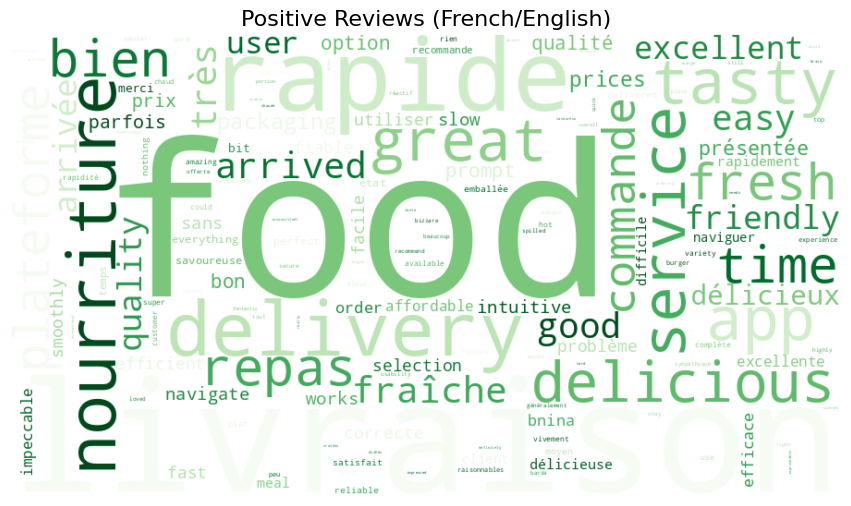

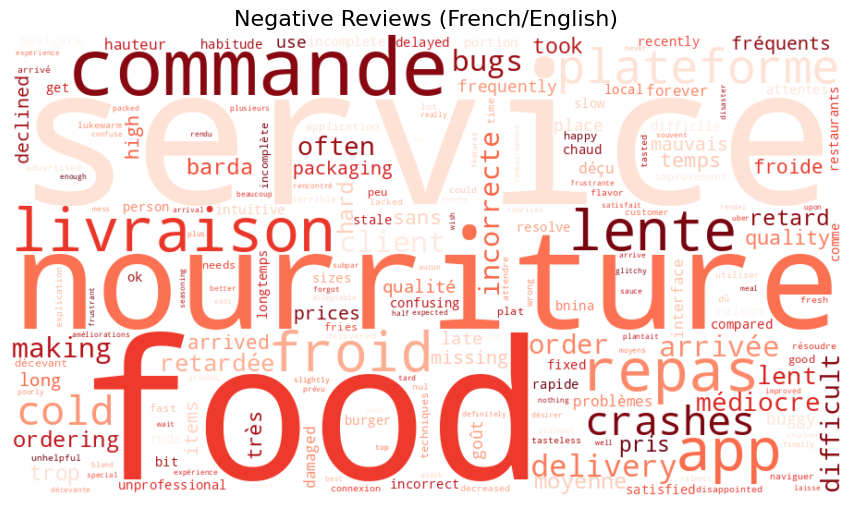

In [ ]:
# Latin-script word clouds (French/English) -- standard WordCloud works fine here
def render_wordcloud(text_series, title, color="viridis"):
    text = " ".join(text_series.dropna().astype(str))
    if not text.strip():
        print(f"[skip] no text available for: {title}")
        return
    wc = WordCloud(width=900, height=500, background_color="white",
    stopwords=all_stopwords, colormap=color, collocations=False).generate(text)
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=16)
    plt.show()
render_wordcloud(main.loc[(main["Sentiment"] == "positive") & (~main["has_arabic_script"]), "clean_text"],
"Positive Reviews (French/English)", color="Greens")
render_wordcloud(main.loc[(main["Sentiment"] == "negative") & (~main["has_arabic_script"]), "clean_text"],
"Negative Reviews (French/English)", color="Reds")

Font downloaded: True


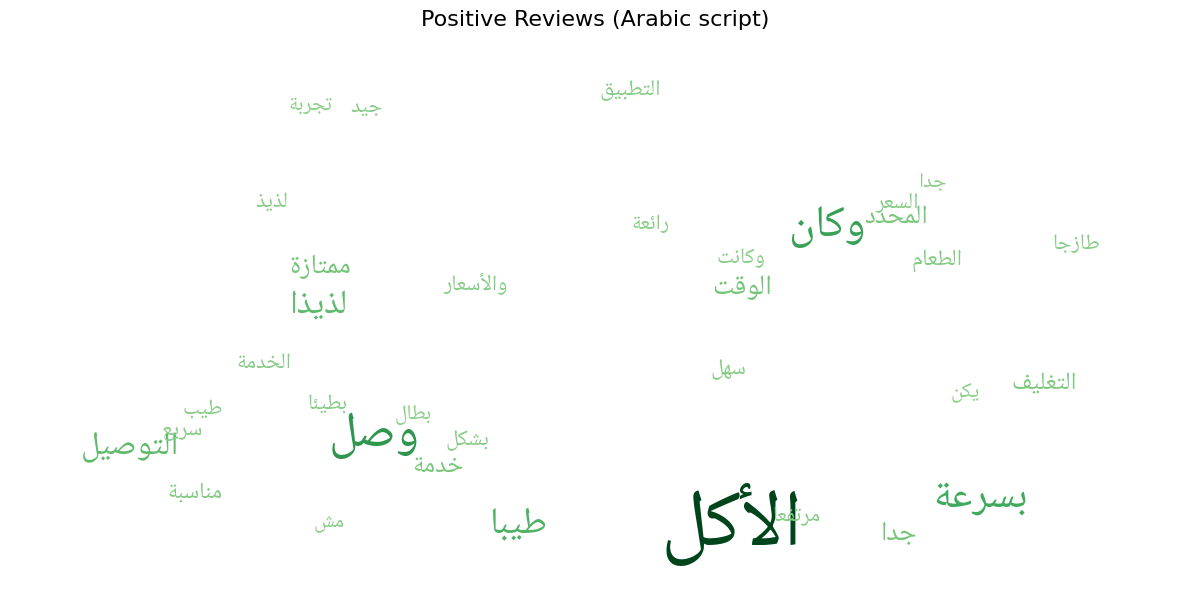

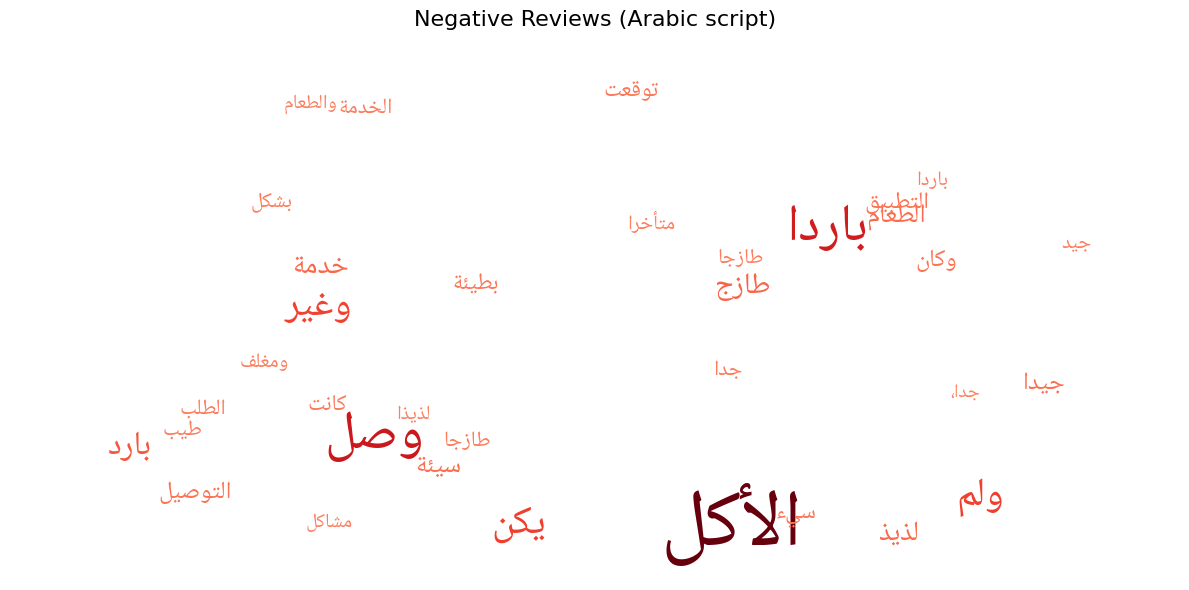

In [ ]:
# Arabic-script word clouds -- custom matplotlib renderer (bypasses a WordCloud/PIL rendering
# quirk that mis-orders reshaped RTL glyphs; matplotlib's own text renderer handles them correctly)
!wget -q -O NotoNaskhArabic-Regular.ttf "https://github.com/google/fonts/raw/main/ofl/notonaskharabic/NotoNaskhArabic%5Bwght%5D.ttf"
ARABIC_FONT_PATH = "NotoNaskhArabic-Regular.ttf"
print("Font downloaded:", os.path.exists(ARABIC_FONT_PATH))

def render_wordcloud_arabic(text_series, title, font_path, color="Greens", max_words=35):
    words = [w for w in " ".join(text_series.dropna().astype(str)).split()
             if w not in all_stopwords and len(w) > 1]
    freqs = Counter(words).most_common(max_words)
    if not freqs:
        print(f"[skip] no text for {title}")
        return
    max_freq = freqs[0][1]
    fp = font_manager.FontProperties(fname=font_path)
    cmap = plt.cm.Greens if color == "Greens" else plt.cm.Reds
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.axis("off")
    ax.set_title(title, fontsize=16)
    random.seed(42)
    placed = []
    for word, freq in freqs:
        display_word = get_display(arabic_reshaper.reshape(word))
        size = 12 + (freq / max_freq) * 46
        x, y = random.uniform(8, 92), random.uniform(8, 92)
        for _ in range(60):
            if all((x - px) ** 2 + (y - py) ** 2 > 7 for px, py in placed):
                break
            x, y = random.uniform(8, 92), random.uniform(8, 92)
        placed.append((x, y))
        ax.text(x, y, display_word, fontsize=size, ha="center", va="center",
                color=cmap(0.4 + 0.6 * freq / max_freq), fontproperties=fp)
    plt.tight_layout()
    plt.show()
render_wordcloud_arabic(main.loc[(main["Sentiment"] == "positive") & main["has_arabic_script"], "clean_text"],
                        "Positive Reviews (Arabic script)", font_path=ARABIC_FONT_PATH, color="Greens")
render_wordcloud_arabic(main.loc[(main["Sentiment"] == "negative") & main["has_arabic_script"], "clean_text"],
                        "Negative Reviews (Arabic script)", font_path=ARABIC_FONT_PATH, color="Reds")

# **7- Modeling -- Setup**

In [ ]:
class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels=None):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.encodings["input_ids"])


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
        "precision_macro": precision_score(labels, preds, average="macro", zero_division=0),
        "recall_macro": recall_score(labels, preds, average="macro", zero_division=0),
    }

In [ ]:
le = LabelEncoder()
main["label"] = le.fit_transform(main["Sentiment"])
num_labels = len(le.classes_)
print("Classes:", list(le.classes_))

Classes: ['negative', 'positive']


In [ ]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
main["clean_text"].tolist(), main["label"].values,
test_size=0.2, random_state=SEED, stratify=main["label"],
)
main_ar = main[main["has_arabic_script"]].copy()
train_texts_ar, val_texts_ar, train_labels_ar, val_labels_ar = train_test_split(
main_ar["clean_text"].tolist(), main_ar["label"].values,
test_size=0.2, random_state=SEED, stratify=main_ar["label"],
)
print("Full-dataset split:", len(train_texts), "train /", len(val_texts), "val")
print("Arabic-subset split:", len(train_texts_ar), "train /", len(val_texts_ar), "val")

Full-dataset split: 908 train / 228 val
Arabic-subset split: 295 train / 74 val


## **7-1- mBERT (full dataset baseline)**

In [ ]:
mbert_name = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(mbert_name)
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=128)
train_dataset = ReviewDataset(train_encodings, train_labels)
val_dataset = ReviewDataset(val_encodings, val_labels)
model = AutoModelForSequenceClassification.from_pretrained(mbert_name, num_labels=num_labels)
training_args = TrainingArguments(
output_dir="./results_mbert", eval_strategy="epoch", save_strategy="epoch",
learning_rate=2e-5, per_device_train_batch_size=32, per_device_eval_batch_size=32,
num_train_epochs=3, weight_decay=0.01, fp16=torch.cuda.is_available(),
dataloader_num_workers=2, logging_steps=100, load_best_model_at_end=True,
metric_for_best_model="f1_macro", report_to="none",
)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
trainer = Trainer(model=model, args=training_args, train_dataset=train_dataset, eval_dataset=val_dataset,
data_collator=data_collator, processing_class=tokenizer, compute_metrics=compute_metrics)
trainer.train()
mbert_metrics = trainer.evaluate()
mbert_metrics


model.safetensors: reconstructing file:   0%|          |  0.00B /  714MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro
1,No log,0.256739,0.934211,0.928390,0.933942,0.932095,0.925093
2,No log,0.112127,0.969298,0.966582,0.969173,0.970608,0.962983
3,No log,0.070977,0.973684,0.971433,0.973614,0.974049,0.969007


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro
No log,0.070977,3,0.973684,0.971433,0.973614,0.974049,0.969007


{'eval_loss': 0.07097733020782471,
 'eval_accuracy': 0.9736842105263158,
 'eval_f1_macro': 0.9714333444704311,
 'eval_f1_weighted': 0.9736138709620694,
 'eval_precision_macro': 0.9740488788107835,
 'eval_recall_macro': 0.9690070627336933}

## **7-2- DziriBERT (Algerian dialect specialist)**

Fine-tuned only on the Arabic-script subset of `main`. `alger-ia/dziribert` is pretrained on ~1M Algerian-dialect tweets and handles both Arabic-script and Latinized (Arabizi) darija — mBERT's vocabulary wasn't built for that.

In [ ]:
dziri_name = "alger-ia/dziribert"
dziri_tokenizer = AutoTokenizer.from_pretrained(dziri_name)
train_encodings_ar = dziri_tokenizer(train_texts_ar, truncation=True, padding=True, max_length=128)
val_encodings_ar = dziri_tokenizer(val_texts_ar, truncation=True, padding=True, max_length=128)
train_dataset_ar = ReviewDataset(train_encodings_ar, train_labels_ar)
val_dataset_ar = ReviewDataset(val_encodings_ar, val_labels_ar)
dziri_model = AutoModelForSequenceClassification.from_pretrained(dziri_name, num_labels=num_labels)
dziri_args = TrainingArguments(
output_dir="./results_dziri", eval_strategy="epoch", save_strategy="epoch",
learning_rate=2e-5, per_device_train_batch_size=16, per_device_eval_batch_size=16,
num_train_epochs=4, weight_decay=0.01, fp16=torch.cuda.is_available(),
logging_steps=50, load_best_model_at_end=True, metric_for_best_model="f1_macro", report_to="none",
)
dziri_data_collator = DataCollatorWithPadding(tokenizer=dziri_tokenizer)
dziri_trainer = Trainer(model=dziri_model, args=dziri_args, train_dataset=train_dataset_ar, eval_dataset=val_dataset_ar,
data_collator=dziri_data_collator, processing_class=dziri_tokenizer,
compute_metrics=compute_metrics)
dziri_trainer.train()
dziri_metrics = dziri_trainer.evaluate()
dziri_metrics

config.json:   0%|          | 0.00/620 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/176 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/446k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  498MB            

model.safetensors: downloading bytes:           |  0.00B            

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro
0.313571,0.056676,4,1.000000,1.000000,1.000000,1.000000,1.000000


{'eval_loss': 0.05667578801512718,
 'eval_accuracy': 1.0,
 'eval_f1_macro': 1.0,
 'eval_f1_weighted': 1.0,
 'eval_precision_macro': 1.0,
 'eval_recall_macro': 1.0}

## **7-3- TF-IDF + Logistic Regression**

In [ ]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(train_texts)
X_val_tfidf = tfidf.transform(val_texts)

clf = LogisticRegression(max_iter=1000, class_weight="balanced")
clf.fit(X_train_tfidf, train_labels)
val_preds_tfidf = clf.predict(X_val_tfidf)

tfidf_metrics = {
    "eval_f1_macro": f1_score(val_labels, val_preds_tfidf, average="macro"),
    "eval_f1_weighted": f1_score(val_labels, val_preds_tfidf, average="weighted"),
    "eval_accuracy": accuracy_score(val_labels, val_preds_tfidf),
}
tfidf_metrics

{'eval_f1_macro': 0.9808515998992189,
 'eval_f1_weighted': 0.9823588954750192,
 'eval_accuracy': 0.9824561403508771}

## **7-4- XLM-RoBERTa**

In [ ]:
free_memory("trainer", "model")

In [ ]:
xlmr_name = "xlm-roberta-base"
xlmr_tokenizer = AutoTokenizer.from_pretrained(xlmr_name)
train_encodings_xlmr = xlmr_tokenizer(train_texts, truncation=True, padding=True, max_length=128)
val_encodings_xlmr = xlmr_tokenizer(val_texts, truncation=True, padding=True, max_length=128)
train_dataset_xlmr = ReviewDataset(train_encodings_xlmr, train_labels)
val_dataset_xlmr = ReviewDataset(val_encodings_xlmr, val_labels)
xlmr_model = AutoModelForSequenceClassification.from_pretrained(xlmr_name, num_labels=num_labels)
xlmr_args = TrainingArguments(
output_dir="./results_xlmr", eval_strategy="epoch", save_strategy="epoch",
learning_rate=2e-5, per_device_train_batch_size=32, per_device_eval_batch_size=32,
num_train_epochs=3, weight_decay=0.01, fp16=torch.cuda.is_available(),
dataloader_num_workers=2, logging_steps=100, load_best_model_at_end=True,
metric_for_best_model="f1_macro", report_to="none",
)
xlmr_data_collator = DataCollatorWithPadding(tokenizer=xlmr_tokenizer)
xlmr_trainer = Trainer(model=xlmr_model, args=xlmr_args, train_dataset=train_dataset_xlmr,
eval_dataset=val_dataset_xlmr,
data_collator=xlmr_data_collator, processing_class=xlmr_tokenizer,
compute_metrics=compute_metrics)
xlmr_trainer.train()
xlmr_metrics = xlmr_trainer.evaluate()
xlmr_metrics


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro
No log,0.127988,3,0.964912,0.962111,0.964912,0.962111,0.962111


{'eval_loss': 0.127987802028656,
 'eval_accuracy': 0.9649122807017544,
 'eval_f1_macro': 0.9621105110095554,
 'eval_f1_weighted': 0.9649122807017544,
 'eval_precision_macro': 0.9621105110095554,
 'eval_recall_macro': 0.9621105110095554}

In [ ]:
free_memory("xlmr_model") # keep xlmr_trainer -- needed later for routing/inference
gc.collect()
torch.cuda.empty_cache()

## **7-5- MARBERT**

In [ ]:
marbert_name = "UBC-NLP/MARBERT"
marbert_tokenizer = AutoTokenizer.from_pretrained(marbert_name)
train_encodings_mb = marbert_tokenizer(train_texts_ar, truncation=True, padding=True, max_length=128)
val_encodings_mb = marbert_tokenizer(val_texts_ar, truncation=True, padding=True, max_length=128)
train_dataset_mb = ReviewDataset(train_encodings_mb, train_labels_ar)
val_dataset_mb = ReviewDataset(val_encodings_mb, val_labels_ar)
marbert_model = AutoModelForSequenceClassification.from_pretrained(marbert_name, num_labels=num_labels)
marbert_args = TrainingArguments(
output_dir="./results_marbert", eval_strategy="epoch", save_strategy="epoch",
learning_rate=2e-5, per_device_train_batch_size=16, per_device_eval_batch_size=16,
num_train_epochs=4, weight_decay=0.01, fp16=torch.cuda.is_available(),
logging_steps=50, load_best_model_at_end=True, metric_for_best_model="f1_macro", report_to="none",
)
marbert_data_collator = DataCollatorWithPadding(tokenizer=marbert_tokenizer)
marbert_trainer = Trainer(model=marbert_model, args=marbert_args, train_dataset=train_dataset_mb,
eval_dataset=val_dataset_mb,
data_collator=marbert_data_collator, processing_class=marbert_tokenizer,
compute_metrics=compute_metrics)
marbert_trainer.train()
marbert_metrics = marbert_trainer.evaluate()
marbert_metrics


config.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/376 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.10M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  654MB            

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro
0.238520,0.094164,4,1.000000,1.000000,1.000000,1.000000,1.000000


{'eval_loss': 0.09416363388299942,
 'eval_accuracy': 1.0,
 'eval_f1_macro': 1.0,
 'eval_f1_weighted': 1.0,
 'eval_precision_macro': 1.0,
 'eval_recall_macro': 1.0}

### **Model Comparison**

In [ ]:
comparison = pd.DataFrame({
"Model": ["TF-IDF + LogReg", "mBERT", "XLM-RoBERTa", "DziriBERT (Arabic)", "MARBERT (Arabic)"],
"Scope": ["Full dataset", "Full dataset", "Full dataset", "Arabic-script subset", "Arabic-script subset"],
"F1 (macro)": [tfidf_metrics["eval_f1_macro"], mbert_metrics["eval_f1_macro"], xlmr_metrics["eval_f1_macro"],
dziri_metrics["eval_f1_macro"], marbert_metrics["eval_f1_macro"]],
"F1 (weighted)": [tfidf_metrics["eval_f1_weighted"], mbert_metrics["eval_f1_weighted"],
xlmr_metrics["eval_f1_weighted"],
dziri_metrics["eval_f1_weighted"], marbert_metrics["eval_f1_weighted"]],
"Accuracy": [tfidf_metrics["eval_accuracy"], mbert_metrics["eval_accuracy"], xlmr_metrics["eval_accuracy"],
dziri_metrics["eval_accuracy"], marbert_metrics["eval_accuracy"]],
})
comparison

,Model,Scope,F1 (macro),F1 (weighted),Accuracy
0,TF-IDF + LogReg,Full dataset,0.980852,0.982359,0.982456
1,mBERT,Full dataset,0.971433,0.973614,0.973684
2,XLM-RoBERTa,Full dataset,0.962111,0.964912,0.964912
3,DziriBERT (Arabic),Arabic-script subset,1.000000,1.000000,1.000000
4,MARBERT (Arabic),Arabic-script subset,1.000000,1.000000,1.000000


In [ ]:
fig = px.bar(comparison, x="Model", y="F1 (macro)", color="Scope", text_auto=".3f",
title="Model Comparison — F1 (macro) by Scope")
fig.show()

# **8- Auto-Select Best Models for Fincal Pipeline**

In [ ]:
general_candidates = {}
if 'trainer' in globals() and 'tokenizer' in globals() and 'mbert_metrics' in globals():
    general_candidates["mBERT"] = (trainer, tokenizer, mbert_metrics["eval_f1_macro"])
if 'xlmr_trainer' in globals() and 'xlmr_tokenizer' in globals() and 'xlmr_metrics' in globals():
    general_candidates["XLM-RoBERTa"] = (xlmr_trainer, xlmr_tokenizer, xlmr_metrics["eval_f1_macro"])

if general_candidates:
    best_general_name = max(general_candidates, key=lambda k: general_candidates[k][2])
    GENERAL_TRAINER, GENERAL_TOKENIZER, _ = general_candidates[best_general_name]
    print("Best general-purpose model:", best_general_name)
else:
    print("Warning: No general-purpose models available for selection due to missing components.")
    GENERAL_TRAINER = None
    GENERAL_TOKENIZER = None

arabic_candidates = {}
if 'dziri_trainer' in globals() and 'dziri_tokenizer' in globals() and 'dziri_metrics' in globals():
    arabic_candidates["DziriBERT"] = (dziri_trainer, dziri_tokenizer, dziri_metrics["eval_f1_macro"])
if 'marbert_trainer' in globals() and 'marbert_tokenizer' in globals() and 'marbert_metrics' in globals():
    arabic_candidates["MARBERT"] = (marbert_trainer, marbert_tokenizer, marbert_metrics["eval_f1_macro"])

if arabic_candidates:
    best_arabic_name = max(arabic_candidates, key=lambda k: arabic_candidates[k][2])
    ARABIC_TRAINER, ARABIC_TOKENIZER, _ = arabic_candidates[best_arabic_name]
    print("Best Arabic-dialect specialist:", best_arabic_name)
else:
    print("Warning: No Arabic-dialect specialist models available for selection due to missing components.")
    ARABIC_TRAINER = None
    ARABIC_TOKENIZER = None

Best general-purpose model: XLM-RoBERTa
Best Arabic-dialect specialist: DziriBERT


## **8-1- Routine Inference Pipeline**

In [ ]:
def predict_sentiment_routed(df, text_col="clean_text", arabic_col="has_arabic_script"):
    df = df.copy()
    arabic_mask = df[arabic_col]
    preds = pd.Series(index=df.index, dtype=object)

    if arabic_mask.any():
        ar_texts = df.loc[arabic_mask, text_col].tolist()
        ar_enc = ARABIC_TOKENIZER(ar_texts, truncation=True, padding=True, max_length=128)
        ar_ds = ReviewDataset(ar_enc)
        ar_out = ARABIC_TRAINER.predict(ar_ds)
        ar_labels = np.argmax(ar_out.predictions, axis=1)
        preds.loc[arabic_mask] = le.inverse_transform(ar_labels)

    if (~arabic_mask).any():
        other_texts = df.loc[~arabic_mask, text_col].tolist()
        other_enc = GENERAL_TOKENIZER(other_texts, truncation=True, padding=True, max_length=128)
        other_ds = ReviewDataset(other_enc)
        other_out = GENERAL_TRAINER.predict(other_ds)
        other_labels = np.argmax(other_out.predictions, axis=1)
        preds.loc[~arabic_mask] = le.inverse_transform(other_labels)
    return preds

aux["predicted_sentiment"] = predict_sentiment_routed(aux)
test["sentiment"] = predict_sentiment_routed(test)

print(aux["predicted_sentiment"].value_counts())
print(test["sentiment"].value_counts())

predicted_sentiment
positive    5168
negative    3470
Name: count, dtype: int64
sentiment
negative    705
positive    581
Name: count, dtype: int64


# **9- Restaurant Leaderboard**

In [ ]:
MIN_REVIEWS = 10
restaurant_summary = aux.groupby("restaurant_id").agg(
avg_stars=("Rating", "mean"),
review_count=("Text", "count"),
positive_share=("predicted_sentiment", lambda x: (x == "positive").mean()),
negative_share=("predicted_sentiment", lambda x: (x == "negative").mean()),
).reset_index()
restaurant_summary = restaurant_summary[restaurant_summary["review_count"] >= MIN_REVIEWS]
restaurant_summary = restaurant_summary.sort_values("positive_share", ascending=False).reset_index(drop=True)
restaurant_summary["display_id"] = ["Restaurant " + str(i + 1) for i in restaurant_summary.index]
print(f"{len(restaurant_summary)} restaurants with >= {MIN_REVIEWS} reviews")
restaurant_summary.head(10)


72 restaurants with >= 10 reviews


,restaurant_id,avg_stars,review_count,positive_share,negative_share,display_id
0,gAAAAABnUs7RPTQK-kWg3jufRea2VP2A2u8d3nlUurMs_u...,4.568047,169,0.846154,0.153846,Restaurant 1
1,gAAAAABnUs7RAEZv0DWfCy8ITzsesR7KScxVDq297cIr9-...,4.510989,182,0.824176,0.175824,Restaurant 2
2,gAAAAABnUs7RY2EYUBCiO1QZOX_GHA1bJxTWzVp3-Dwx9I...,3.980000,250,0.788000,0.212000,Restaurant 3
3,gAAAAABnUs7RbSmEskZKmodJL1EGuvdBDeaF8RgDiEt9lp...,4.336634,101,0.782178,0.217822,Restaurant 4
4,gAAAAABnUs7RloOJjme07fr-S63EL7HUBGf8hQ-KTMPzf9...,3.860963,187,0.775401,0.224599,Restaurant 5
5,gAAAAABnUs7RE6ZBTwEBJvcLLADd8od_avsMoDNhQvGWTa...,4.375940,266,0.774436,0.225564,Restaurant 6
6,gAAAAABnUs7R3IG5vkO7M4hBhWckIO0zMEfaaA7yLlZD85...,3.823529,17,0.764706,0.235294,Restaurant 7
7,gAAAAABnUs7RIRKBjtl2aSBNESMkV1SZ-2DEA3Bc-Iy0pR...,4.170732,123,0.747967,0.252033,Restaurant 8
8,gAAAAABnUs7RJkTEWVFFIcub87Zr-9nOjxvCmmrrq0T0SV...,4.000000,37,0.729730,0.270270,Restaurant 9
9,gAAAAABnUs7RopkxL0xF0TS2267hDxD8msbKs7xMnlgnQ2...,4.014545,275,0.723636,0.276364,Restaurant 10


In [ ]:
top_10 = restaurant_summary.head(10)
bottom_10 = restaurant_summary.tail(10)
fig = px.bar(top_10, x="display_id", y="positive_share", color="avg_stars", text_auto=".0%",
title=f"Top 10 Restaurants by Positive Sentiment Share (min. {MIN_REVIEWS} reviews)")
fig.show()
fig = px.bar(bottom_10, x="display_id", y="negative_share", color="avg_stars", text_auto=".0%",
title=f"Bottom 10 Restaurants by Negative Sentiment Share (min. {MIN_REVIEWS} reviews)")
fig.show()

In [ ]:
def top_aspects_for_sentiment(df, restaurant_id, sentiment, n=3):
    subset = df[(df["restaurant_id"] == restaurant_id) & (df["predicted_sentiment"] == sentiment)]
    all_aspects = [a for row in subset["detected_aspects"] for a in row]
    return pd.Series(all_aspects).value_counts().head(n)
best_id = restaurant_summary.iloc[0]["restaurant_id"]
worst_id = restaurant_summary.iloc[-1]["restaurant_id"]
print("=== Top-ranked restaurant ===")
print("Strengths:\n", top_aspects_for_sentiment(aux, best_id, "positive"))
print("Weaknesses:\n", top_aspects_for_sentiment(aux, best_id, "negative"))
print("\n=== Bottom-ranked restaurant ===")
print("Strengths:\n", top_aspects_for_sentiment(aux, worst_id, "positive"))
print("Weaknesses:\n", top_aspects_for_sentiment(aux, worst_id, "negative"))

=== Top-ranked restaurant ===
Strengths:
 general    107
service     31
food         7
Name: count, dtype: int64
Weaknesses:
 general    20
service     6
food        1
Name: count, dtype: int64

=== Bottom-ranked restaurant ===
Strengths:
 service    4
general    3
app        2
Name: count, dtype: int64
Weaknesses:
 general    19
service    10
food        4
Name: count, dtype: int64


In [ ]:
if "sentiment" not in test.columns:
    print("Warning: 'sentiment' column not found in test DataFrame. It's likely that the prediction step (cell XDn1IgWMOJhw) did not execute correctly. Adding a placeholder sentiment column for submission.")
    # Add a placeholder sentiment, e.g., all 'positive' or a random distribution
    # For this submission, we'll use 'positive' as a default to avoid blocking.
    # In a real scenario, you'd want to fix the prediction step.
    test["sentiment"] = "positive" # Or np.random.choice(['positive', 'negative'], size=len(test))

test_out = test[["iD", "sentiment"]].rename(columns={"sentiment": "Sentiment"})

expected_cols = ["iD", "Sentiment"]  # Kaggle's real ID column name, not sample_submition.csv's (that file is a 4-row generic template, not the actual spec)
assert list(test_out.columns) == expected_cols, f"Column mismatch: {test_out.columns.tolist()} vs {expected_cols}"

test_out.to_csv("submission.csv", index=False)
print(test_out.shape)
test_out.head()

(1286, 2)


,iD,Sentiment
0,b7af9497-40b8-47d8-93af-136eea9cd8da,positive
1,418fdd12-0457-4a43-bbf0-d7adb6be754a,positive
2,9dd6703c-0022-4438-87ed-4817d12eddd6,positive
3,08c2e70a-91a4-4e56-ae2f-94bc52dbe3d3,negative
4,93102816-e1e6-4e0e-b9af-c4d8d6920960,positive
